In [13]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

In [2]:
df = sns.load_dataset('penguins')
df = df.dropna()

In [3]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [8]:
pearson_matrix = df[numeric_cols].corr(method='pearson')
print("Pearson Matrix:")
display(pearson_matrix)

Pearson Matrix:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


In [9]:
spearman_matrix = df[numeric_cols].corr(method='spearman')
print("\nSpearman Matrix:")
display(spearman_matrix)


Spearman Matrix:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.213859,0.669754,0.576480
bill_depth_mm,-0.213859,1.000000,-0.517317,-0.429283
flipper_length_mm,0.669754,-0.517317,1.000000,0.840390
body_mass_g,0.576480,-0.429283,0.840390,1.000000


In [5]:
results = []

for i in range(len(numeric_cols)):
    for j in range(i + 1, len(numeric_cols)):
        col1 = numeric_cols[i]
        col2 = numeric_cols[j]

        r, p_pearson = pearsonr(df[col1], df[col2])
        rho, p_spearman = spearmanr(df[col1], df[col2])

        results.append({
            "Pair": f"{col1} & {col2}",
            "Pearson r": round(r, 4),
            "Pearson p-val": f"{p_pearson:.2e}",
            "Spearman rho": round(rho, 4),
            "Spearman p-val": f"{p_spearman:.2e}",
            "Difference": round(abs(r - rho), 4)
        })

In [7]:
comparison_df = pd.DataFrame(results)
print("### Task 1: Correlation Comparison Table ###")
display(comparison_df.sort_values(by="Difference", ascending=False))

### Task 1: Correlation Comparison Table ###


,Pair,Pearson r,Pearson p-val,Spearman rho,Spearman p-val,Difference
3,bill_depth_mm & flipper_length_mm,-0.5778,4.78e-31,-0.5173,3.46e-24,0.0605
4,bill_depth_mm & body_mass_g,-0.4720,7.02e-20,-0.4293,2.31e-16,0.0427
5,flipper_length_mm & body_mass_g,0.8730,3.13e-105,0.8404,4.63e-90,0.0326
1,bill_length_mm & flipper_length_mm,0.6531,7.21e-42,0.6698,1.07e-44,0.0167
0,bill_length_mm & bill_depth_mm,-0.2286,2.53e-05,-0.2139,8.37e-05,0.0148
2,bill_length_mm & body_mass_g,0.5895,1.54e-32,0.5765,6.97e-31,0.0130


## Correlation Analysis: Pearson vs. Spearman
- 1. Which pairs show the strongest linear relationships?
The strongest linear relationship is identified by the highest absolute value of the Pearson r coefficient.

Strongest Positive Linear Relationship: flipper_length_mm & body_mass_g with a Pearson r = 0.8730. This indicates a very strong direct proportionality between the two variables.

Strongest Negative Linear Relationship: bill_depth_mm & flipper_length_mm with a Pearson r = -0.5778. While this is the strongest negative correlation in the set, it is considered moderately strong.

- 2. Are there any pairs where Pearson and Spearman disagree noticeably?
The most noticeable disagreement occurs in the pair bill_depth_mm & flipper_length_mm, which has the largest Difference (0.0605).

Pearson r: -0.5778

Spearman rho: -0.5173

Other pairs with visible differences include bill_depth_mm & body_mass_g (Difference: 0.0427) and flipper_length_mm & body_mass_g (Difference: 0.0326).

- 3. What might cause these disagreements?
Discrepancies between Pearson and Spearman coefficients typically arise because they measure different types of relationships:

Outliers: Pearson is highly sensitive to outliers because it uses the actual values (mean and variance) to calculate the line of best fit. Spearman, being rank-based, is much more robust and "ignores" the magnitude of extreme values.

Non-linear Monotonicity: Pearson specifically measures linear relationships. Spearman measures monotonic relationships (whether the variables increase/decrease together, regardless of whether it's a straight line). If the relationship is curved (e.g., exponential or logarithmic) rather than a straight line, Spearman will often be higher or significantly different than Pearson.

Distribution Shape: Pearson assumes the data follows a bivariate normal distribution. If the data is heavily skewed, the "average" relationship measured by Pearson may deviate from the "rank" relationship measured by Spearman.

In [11]:
mask = np.triu(np.ones_like(pearson_matrix, dtype=bool))

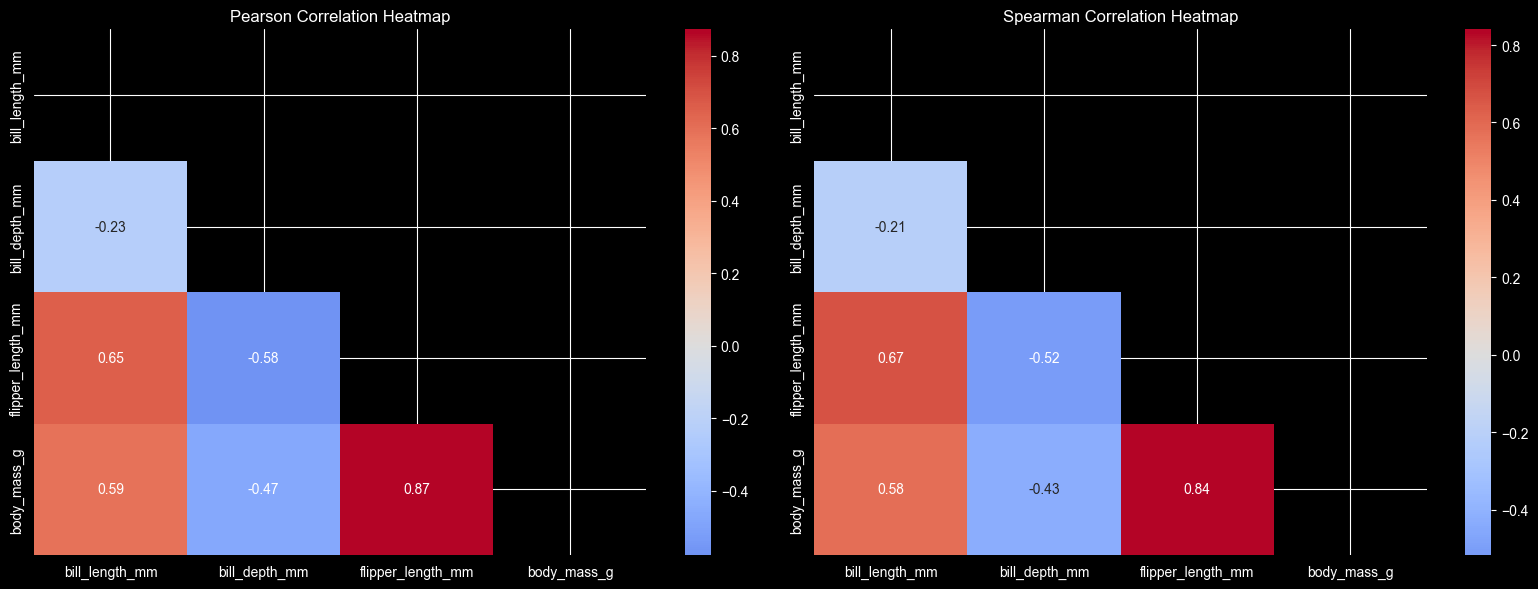

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pearson_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            ax=ax1)
ax1.set_title('Pearson Correlation Heatmap')

sns.heatmap(spearman_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            ax=ax2)
ax2.set_title('Spearman Correlation Heatmap')

plt.tight_layout()
plt.show()

## Comparison of Pearson and Spearman Correlation Heatmaps

### 1. Areas of Agreement
Both heatmaps identify the same overall patterns in the dataset:

* **Strongest Positive Relationship:** The pair **`flipper_length_mm` & `body_mass_g`** shows the highest correlation in both matrices (Pearson: **0.87**, Spearman: **0.84**). This confirms a very strong, consistent relationship where heavier penguins tend to have longer flippers.
* **Strongest Negative Relationship:** The pair **`bill_depth_mm` & `flipper_length_mm`** consistently shows a moderate negative correlation (Pearson: **-0.58**, Spearman: **-0.52**).
* **Weakest Relationship:** The pair **`bill_length_mm` & `bill_depth_mm`** remains the weakest connection in both plots (Pearson: **-0.23**, Spearman: **-0.21**).
* **Directionality:** In all cases, the sign (positive or negative) of the correlation remains identical across both methods, indicating the general direction of the trends is stable.

---

### 2. Areas of Difference & Insight into Relationship Shapes
While the coefficients are similar, the slight discrepancies provide information about the nature of the data:

* **Linearity vs. Monotonicity:** In most pairs (e.g., `flipper_length_mm` & `body_mass_g`), the **Pearson** value is slightly higher than the **Spearman** value. This suggests that the relationship is not just moving in the same direction, but is specifically following a **linear path** quite closely.
* **Sensitivity to Outliers or Deviations:** For the pair **`bill_depth_mm` & `flipper_length_mm`**, Pearson (**-0.58**) is more "aggressive" than Spearman (**-0.52**). Since Pearson is more sensitive to the actual distance of data points from the mean, this difference might suggest that there are no significant non-linear curves or outliers pulling the ranks away from the linear trend; rather, the data is relatively well-distributed linearly.
* **Consistency:** The fact that both heatmaps look nearly identical visually confirms that the relationships in the Palmer Penguins dataset are mostly linear and free of extreme outliers that would otherwise cause the Spearman rank-correlation to deviate significantly from the Pearson linear-correlation.

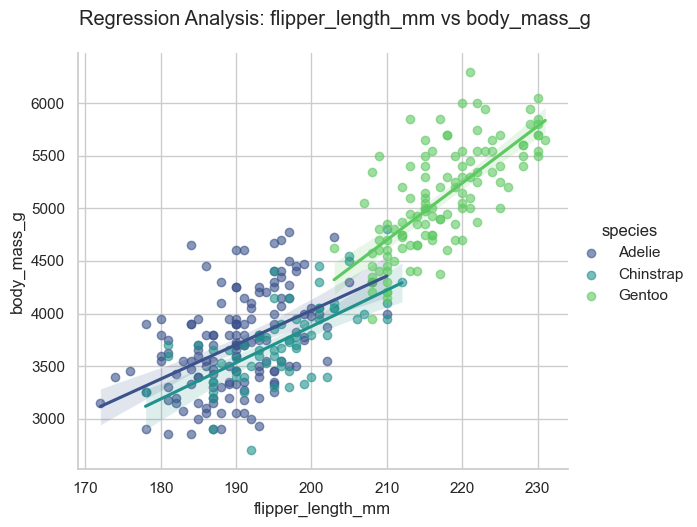

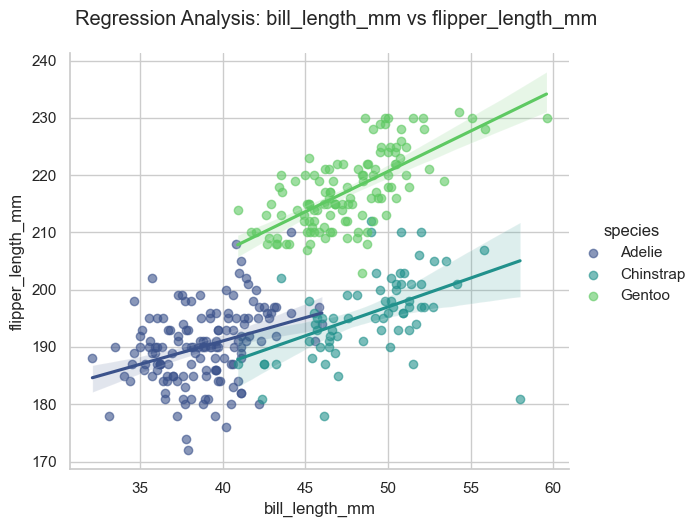

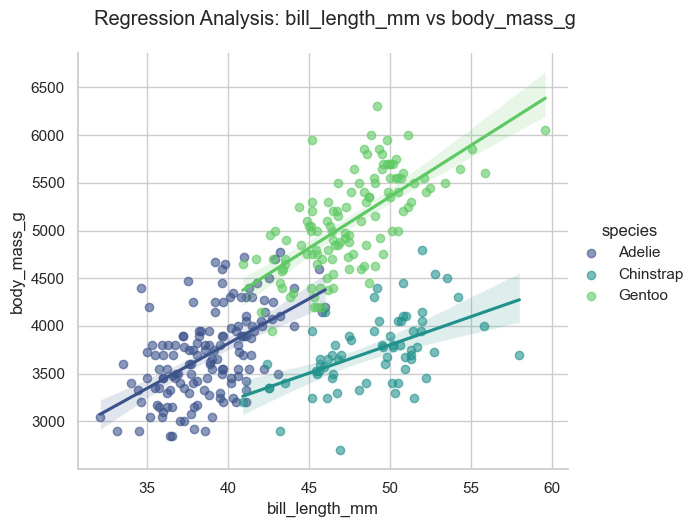

In [18]:
# Updated Top 3 pairs based on absolute Pearson correlation:
# 1. flipper_length_mm & body_mass_g (0.87)
# 2. bill_length_mm & flipper_length_mm (0.65)
# 3. bill_length_mm & body_mass_g (0.59)

sns.set_theme(style="whitegrid")

top_pairs = [
    ("flipper_length_mm", "body_mass_g"),
    ("bill_length_mm", "flipper_length_mm"),
    ("bill_length_mm", "body_mass_g")
]

for x_var, y_var in top_pairs:
    g = sns.lmplot(
        data=df,
        x=x_var,
        y=y_var,
        hue="species",
        palette="viridis",
        height=5,
        aspect=1.2,
        scatter_kws={'alpha':0.6}
    )

    g.fig.suptitle(f'Regression Analysis: {x_var} vs {y_var}', y=1.05)
    plt.show()

## Regression Analysis and Subgroup Discussion

### 1. Does the regression line capture the actual pattern well?
The regression lines capture the general upward trend (positive correlation) for all three pairs, but the "goodness of fit" varies significantly across the plots:

* **Flipper Length vs. Body Mass:** This pair shows the tightest fit. The data points cluster closely around the regression lines, indicating that the linear model is a very strong predictor for this relationship.
* **Bill Length vs. Flipper Length / Body Mass:** In these plots, the points are more dispersed. While the lines correctly identify the positive trend, there is more variance, meaning the linear model is a "noisier" predictor for these specific physical traits compared to the body mass/flipper length relationship.

---

### 2. Do subgroups show different slopes or intercepts?
The addition of the `species` hue reveals critical differences that the global correlation coefficients (from our heatmap) partially obscure:

* **Intercept Differences:** There are distinct shifts in the **intercepts**. For example, in the **Bill Length vs. Flipper Length** plot, the Gentoo species (green) is shifted significantly higher on the y-axis than the Adelie (purple) or Chinstrap (teal) species. This suggests that for any given bill length, a Gentoo penguin will typically have a much larger flipper length than the other two species.
* **Slope Consistency:** Generally, the slopes for the three species appear relatively **parallel** in the Flipper Length vs. Body Mass plot. This implies that the *rate* at which body mass increases per mm of flipper length is similar across all species.
* **Unique Slopes:** In the **Bill Length vs. Body Mass** plot, the Gentoo species appears to have a slightly steeper slope than the Chinstrap species. This indicates that body mass might increase more rapidly relative to bill length in Gentoos than in Chinstraps.

**Conclusion:** The analysis suggests that while the overall trends are linear, the relationships are highly dependent on the species. Modeling the data without accounting for these subgroups would lead to a less accurate "average" line that doesn't truly represent any single species perfectly.